In [6]:
import pandas as pd
import numpy as np
import os
import json
import datetime
import gc
import re
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

from pycaret.regression import *

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
class MercariPyCaretAnalyzer:
    """
    Mercari Price Suggestion Challenge용 PyCaret 분석기
    - TSV/CSV 데이터 로딩
    - TF-IDF / CountVectorizer + TruncatedSVD 차원 축소
    - PyCaret setup & compare_models
    - Base model 생성, 시각화, 예측
    - Metrics JSON 저장, submission CSV 저장
    """

    def __init__(
        self, data_dir="../data", images_dir="../images", results_dir="../results"
    ):
        self.data_dir = data_dir
        self.images_dir = images_dir
        self.results_dir = results_dir

        self.train = None
        self.test = None
        self.best_model = None
        self.setup_result = None
        self.metrics = {}

        os.makedirs(self.images_dir, exist_ok=True)
        os.makedirs(self.results_dir, exist_ok=True)

    # ------------------ 데이터 로딩 ------------------
    def load_data(self, train_file="train.tsv", test_file="test.tsv", sep="\t"):
        import os
        import numpy as np
        import pandas as pd

        print("📂 데이터 로딩 시작...")
        train_path = os.path.join(self.data_dir, train_file)
        test_path = os.path.join(self.data_dir, test_file)

        self.train = pd.read_csv(train_path, sep=sep)
        self.test = pd.read_csv(test_path, sep=sep)

        print(f"original data shape : train {self.train.shape}, test {self.test.shape}")

        print("✅ Price 외 결측치 처리 및 데이터 전처리 시작...")

        # price 0 제거 + NaN 제거 (train만)
        self.train = self.train[self.train["price"] > 0].dropna(subset=["price"])
        print("Price NaN count:", self.train["price"].isna().sum())

        # 카테고리 대/중/소 분리 (train, test 동일)
        for df_name, df in [("train", self.train), ("test", self.test)]:
            df["main_cat"], df["sub_cat"], df["sub_sub_cat"] = zip(
                *df["category_name"].apply(
                    lambda x: x.split("/") if isinstance(x, str) and "/" in x
                    else ["missing", "missing", "missing"]
                )
            )

            # 결측치 처리
            df["brand_name"] = df["brand_name"].fillna("Unknown")
            df["category_name"] = df["category_name"].fillna("Unknown")
            df["item_description"] = df["item_description"].fillna("No description")

            # 인덱스 리셋
            if df_name == "train":
                self.train = df.reset_index(drop=True)
            else:
                self.test = df.reset_index(drop=True)

        # ✅ 로그 변환은 별도 컬럼으로 (시각화 & 모델링용)
        self.train["price_log"] = np.log1p(self.train["price"])

        print("Final Price NaN count:", self.train["price"].isna().sum())
        print("Train length:", len(self.train))

        print("\nTrain head:")
        print(self.train[["price", "price_log"]].head())

        print(f"\nTrain info:\n{'='*50}")
        print(self.train.info())

        print(
            f"\n✅ 데이터 로드 완료: train {self.train.shape}, test {self.test.shape}"
        )


In [7]:
analyzer = MercariPyCaretAnalyzer()

In [8]:
analyzer.load_data()

📂 데이터 로딩 시작...
original data shape : train (1482535, 8), test (693359, 7)
✅ Price 외 결측치 처리 및 데이터 전처리 시작...
Price NaN count: 0
Final Price NaN count: 0
Train length: 1481661

Train head:
   price  price_log
0   10.0   2.397895
1   52.0   3.970292
2   10.0   2.397895
3   35.0   3.583519
4   44.0   3.806662

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1481661 entries, 0 to 1481660
Data columns (total 12 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1481661 non-null  int64  
 1   name               1481661 non-null  object 
 2   item_condition_id  1481661 non-null  int64  
 3   category_name      1481661 non-null  object 
 4   brand_name         1481661 non-null  object 
 5   price              1481661 non-null  float64
 6   shipping           1481661 non-null  int64  
 7   item_description   1481661 non-null  object 
 8   main_cat           1481661 non-null  object 
 9   sub_cat      

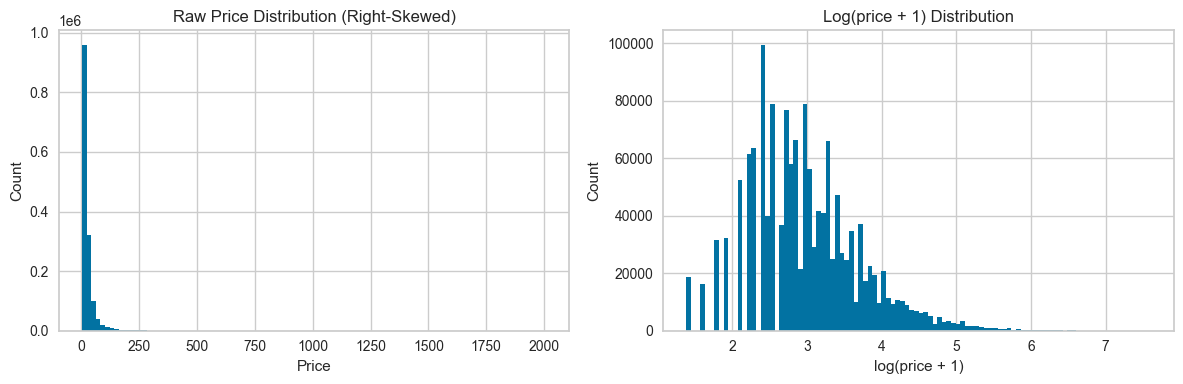

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1️⃣ Raw price 분포 (오른쪽 꼬리 강조)
axes[0].hist(analyzer.train["price"], bins=100)
axes[0].set_title("Raw Price Distribution (Right-Skewed)")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")

# 2️⃣ log(price + 1) 분포
axes[1].hist(analyzer.train["price_log"], bins=100)
axes[1].set_title("Log(price + 1) Distribution")
axes[1].set_xlabel("log(price + 1)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()
